In [1]:
import torch
from torch import nn
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from loader import *

from models.UltraLight_VM_UNet import UltraLight_VM_UNet
from engine import *
import os
import sys

# Set GPU device
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from utils import *
from configs.config_weak import setting_config

import warnings
warnings.filterwarnings("ignore")

def main(config):
    # Add current directory to system path
    sys.path.append(os.getcwd())

    print('#----------Creating logger----------#')
    if not os.path.exists(config.work_dir):
        os.makedirs(config.work_dir)
        
    log_dir = os.path.join(config.work_dir, 'log')
    checkpoint_dir = os.path.join(config.work_dir, 'checkpoints')
    resume_model = os.path.join(checkpoint_dir, 'latest.pth')
    outputs = os.path.join(config.work_dir, 'outputs')
    
    if not os.path.exists(checkpoint_dir): 
        os.makedirs(checkpoint_dir)
    if not os.path.exists(outputs): 
        os.makedirs(outputs)

    global logger
    logger = get_logger('train', log_dir)
    log_config_info(config, logger)

    print('#----------GPU initialization----------#')
    set_seed(config.seed)
    gpu_ids = [0]
    torch.cuda.empty_cache()

    print('#----------Preparing dataset----------#')
    # Use your specified data_path
    train_dataset = isic_loader(path_Data = config.data_path, train = True)
    train_loader = DataLoader(train_dataset,
                                batch_size=config.batch_size, 
                                shuffle=True,
                                pin_memory=True,
                                num_workers=config.num_workers)
                                
    val_dataset = isic_loader(path_Data = config.data_path, train = False)
    val_loader = DataLoader(val_dataset,
                                batch_size=1,
                                shuffle=False,
                                pin_memory=True, 
                                num_workers=config.num_workers,
                                drop_last=True)

    print('#----------Preparing models----------#')
    model_cfg = config.model_config
    model = UltraLight_VM_UNet(num_classes=model_cfg['num_classes'], 
                               input_channels=model_cfg['input_channels'], 
                               c_list=model_cfg['c_list'], 
                               split_att=model_cfg['split_att'], 
                               bridge=model_cfg['bridge'],)
    
    model = model.cuda()

    print('#----------Preparing loss, optimizer, scheduler and AMP----------#')
    criterion = config.criterion
    optimizer = get_optimizer(config, model)
    scheduler = get_scheduler(config, optimizer)
    scaler = GradScaler() if config.amp else None

    min_loss = 999
    start_epoch = 1

    # Resume training from checkpoint
    if os.path.exists(resume_model):
        print('#----------Resuming model----------#')
        checkpoint = torch.load(resume_model, map_location='cuda')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        min_loss = checkpoint['min_loss']

    print('#----------Training start----------#')
    for epoch in range(start_epoch, config.epochs + 1):
        train_one_epoch(train_loader, model, criterion, optimizer, scheduler, epoch, logger, config, scaler=scaler)
        
        # Validation
        loss = val_one_epoch(val_loader, model, criterion, epoch, logger, config)

        if loss < min_loss:
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'best.pth'))
            min_loss = loss
            logger.info(f'Best model saved at epoch {epoch} with loss {min_loss:.4f}')

        # Save latest model
        torch.save({
            'epoch': epoch,
            'min_loss': min_loss,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
        }, resume_model)

    print('✅ Training completed!')

if __name__ == '__main__':
    config = setting_config
    main(config)

/gpfs/work/bio/yixuanli2204/.conda/envs/fyp/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#----------Creating logger----------#
#----------GPU init----------#
#----------Preparing dataset----------#
#----------Prepareing Models----------#
SC_Att_Bridge was used
#----------Prepareing loss, opt, sch and amp----------#
#----------Training Start----------#
train: epoch 1, iter:0, loss: 1.3657, lr: 0.001
train: epoch 1, iter:20, loss: 0.8176, lr: 0.001
train: epoch 1, iter:40, loss: 0.7224, lr: 0.001
train: epoch 1, iter:60, loss: 0.6883, lr: 0.001
train: epoch 1, iter:80, loss: 0.6644, lr: 0.001
train: epoch 1, iter:100, loss: 0.6409, lr: 0.001
train: epoch 1, iter:120, loss: 0.6223, lr: 0.001
train: epoch 1, iter:140, loss: 0.6079, lr: 0.001
train: epoch 1, iter:160, loss: 0.5902, lr: 0.001
train: epoch 1, iter:180, loss: 0.5795, lr: 0.001
train: epoch 1, iter:200, loss: 0.5647, lr: 0.001
train: epoch 1, iter:220, loss: 0.5541, lr: 0.001
train: epoch 1, iter:240, loss: 0.5474, lr: 0.001
train: epoch 1, iter:260, loss: 0.5403, lr: 0.001
train: epoch 1, iter:280, loss: 0.5369, l

100%|██████████| 400/400 [00:04<00:00, 85.01it/s]


val epoch: 1, loss: 0.5744
train: epoch 2, iter:0, loss: 0.4049, lr: 0.0009990232305719944
train: epoch 2, iter:20, loss: 0.4173, lr: 0.0009990232305719944
train: epoch 2, iter:40, loss: 0.4080, lr: 0.0009990232305719944
train: epoch 2, iter:60, loss: 0.4292, lr: 0.0009990232305719944
train: epoch 2, iter:80, loss: 0.4183, lr: 0.0009990232305719944
train: epoch 2, iter:100, loss: 0.4163, lr: 0.0009990232305719944
train: epoch 2, iter:120, loss: 0.4030, lr: 0.0009990232305719944
train: epoch 2, iter:140, loss: 0.3962, lr: 0.0009990232305719944
train: epoch 2, iter:160, loss: 0.3975, lr: 0.0009990232305719944
train: epoch 2, iter:180, loss: 0.3980, lr: 0.0009990232305719944
train: epoch 2, iter:200, loss: 0.3935, lr: 0.0009990232305719944
train: epoch 2, iter:220, loss: 0.3841, lr: 0.0009990232305719944
train: epoch 2, iter:240, loss: 0.3786, lr: 0.0009990232305719944
train: epoch 2, iter:260, loss: 0.3750, lr: 0.0009990232305719944
train: epoch 2, iter:280, loss: 0.3706, lr: 0.000999023

100%|██████████| 400/400 [00:04<00:00, 81.47it/s]


...

val epoch: 48, loss: 0.1583, miou: 0.8020448413191967, f1_or_dsc: 0.8901497043015372, accuracy: 0.9851250076293945,                 specificity: 0.9919495781898594, sensitivity: 0.8910501096402177, confusion_matrix: [[24244565   196763]
 [  193176  1579896]]
train: epoch 49, iter:0, loss: 0.1402, lr: 1.3903222849333505e-05
train: epoch 49, iter:20, loss: 0.1705, lr: 1.3903222849333505e-05
train: epoch 49, iter:40, loss: 0.1703, lr: 1.3903222849333505e-05
train: epoch 49, iter:60, loss: 0.1720, lr: 1.3903222849333505e-05
train: epoch 49, iter:80, loss: 0.1721, lr: 1.3903222849333505e-05
train: epoch 49, iter:100, loss: 0.1753, lr: 1.3903222849333505e-05
train: epoch 49, iter:120, loss: 0.1726, lr: 1.3903222849333505e-05
train: epoch 49, iter:140, loss: 0.1758, lr: 1.3903222849333505e-05
train: epoch 49, iter:160, loss: 0.1768, lr: 1.3903222849333505e-05
train: epoch 49, iter:180, loss: 0.1785, lr: 1.3903222849333505e-05
train: epoch 49, iter:200, loss: 0.1787, lr: 1.3903222849333505e-05

100%|██████████| 400/400 [00:04<00:00, 82.17it/s]


val epoch: 49, loss: 0.1569
train: epoch 50, iter:0, loss: 0.1773, lr: 1.0976769428005579e-05
train: epoch 50, iter:20, loss: 0.1976, lr: 1.0976769428005579e-05
train: epoch 50, iter:40, loss: 0.1925, lr: 1.0976769428005579e-05
train: epoch 50, iter:60, loss: 0.1914, lr: 1.0976769428005579e-05
train: epoch 50, iter:80, loss: 0.1910, lr: 1.0976769428005579e-05
train: epoch 50, iter:100, loss: 0.1830, lr: 1.0976769428005579e-05
train: epoch 50, iter:120, loss: 0.1800, lr: 1.0976769428005579e-05
train: epoch 50, iter:140, loss: 0.1814, lr: 1.0976769428005579e-05
train: epoch 50, iter:160, loss: 0.1827, lr: 1.0976769428005579e-05
train: epoch 50, iter:180, loss: 0.1838, lr: 1.0976769428005579e-05
train: epoch 50, iter:200, loss: 0.1839, lr: 1.0976769428005579e-05
train: epoch 50, iter:220, loss: 0.1827, lr: 1.0976769428005579e-05
train: epoch 50, iter:240, loss: 0.1830, lr: 1.0976769428005579e-05
train: epoch 50, iter:260, loss: 0.1824, lr: 1.0976769428005579e-05
train: epoch 50, iter:280,

100%|██████████| 400/400 [00:04<00:00, 83.13it/s]


val epoch: 50, loss: 0.1570, miou: 0.8019423173446931, f1_or_dsc: 0.8900865578498868, accuracy: 0.9853236389160156,                 specificity: 0.993066947917069, sensitivity: 0.878584174810724, confusion_matrix: [[24271875   169453]
 [  215279  1557793]]
✅ Training Finished!


finetune

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import cv2, os, random, numpy as np, re
from tqdm import tqdm
from models.UltraLight_VM_UNet import UltraLight_VM_UNet
from utils import BceDiceLoss

# --- 1. Dataset Definition ---
class FinetuneDataset(Dataset):
    def __init__(self, img_dir, mask_dir, file_list, size=256):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.size = size
        
        # Pre-check to ensure mask exists
        valid_files = []
        for f in file_list:
            match = re.search(r"ISIC_(\d{7})", f)
            img_id = match.group(1) if match else f.split('.')[0]
            # Support multiple naming formats
            mask_path = os.path.join(mask_dir, f"ISIC_{img_id}_lesion.png")
            if os.path.exists(mask_path):
                valid_files.append(f)
        self.file_list = valid_files

    def __len__(self): 
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        img = cv2.imread(os.path.join(self.img_dir, fname))
        img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (self.size, self.size)) / 255.0
        
        match = re.search(r"ISIC_(\d{7})", fname)
        img_id = match.group(1) if match else fname.split('.')[0]
        mask = cv2.imread(os.path.join(self.mask_dir, f"ISIC_{img_id}_lesion.png"), 0)
        mask = cv2.resize(mask, (self.size, self.size)) / 255.0
        
        return (torch.from_numpy(img).permute(2,0,1).float(), 
                torch.from_numpy(mask).unsqueeze(0).float())

# --- 2. Main Fine-tuning Function (Logic Completed) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def reproducible_finetune():
    DEVICE = "cuda"
    BEST_WEIGHT = "/gpfs/work/bio/yixuanli2204/FYP_Project/code/UltraLight-VM-UNet/results/UltraLight_VM_UNet_ISIC_Combined_20260323_best/checkpoints/best.pth"
    RESTORED_IMG_DIR = "/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/restored_image_final"
    LESION_MASK_DIR = "/gpfs/work/bio/yixuanli2204/FYP_Project/data/gold_real_d2/lesion_mask"

    # A. Split data
    all_files = sorted([f for f in os.listdir(RESTORED_IMG_DIR) if f.endswith('.png')])
    
    # Use Dataset to filter valid files
    temp_ds = FinetuneDataset(RESTORED_IMG_DIR, LESION_MASK_DIR, all_files)
    valid_files = temp_ds.file_list
    
    random.shuffle(valid_files)
    train_files = valid_files[:100]
    test_files = valid_files[100:]

    with open("finetune_train_list.txt", "w") as f:
        f.write("\n".join(train_files))
    print(f"Training list saved to finetune_train_list.txt, available samples: {len(train_files)}")

    # B. Load model
    model = UltraLight_VM_UNet(num_classes=1, c_list=[8,16,24,32,48,64], bridge=True).to(DEVICE)
    ckpt = torch.load(BEST_WEIGHT, map_location=DEVICE)
    state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
    model.load_state_dict({k.replace('module.', ''): v for k, v in state_dict.items()})

    # C. Fine-tuning
    optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
    criterion = BceDiceLoss()
    train_loader = DataLoader(FinetuneDataset(RESTORED_IMG_DIR, LESION_MASK_DIR, train_files), batch_size=8, shuffle=True)

    model.train()
    print("Starting fine-tuning...")
    for epoch in range(30):
        total_loss = 0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/30, Loss: {total_loss/len(train_loader):.4f}")

    # D. Save model
    save_path = "/gpfs/work/bio/yixuanli2204/FYP_Project/weights/vmunet/vmunet_finetuned_fixed_seed.pth"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Fine-tuning completed! Weights saved to: {save_path}")

if __name__ == "__main__":
    reproducible_finetune()

Training list saved to finetune_train_list.txt, available samples: 100
SC_Att_Bridge was used
Starting fine-tuning...
Epoch 5/30, Loss: 0.2463
Epoch 10/30, Loss: 0.1923
Epoch 15/30, Loss: 0.1730
Epoch 20/30, Loss: 0.1595
Epoch 25/30, Loss: 0.1502
Epoch 30/30, Loss: 0.1441
Fine-tuning completed! Weights saved to: /gpfs/work/bio/yixuanli2204/FYP_Project/weights/vmunet/vmunet_finetuned_fixed_seed.pth


/tmp/ipykernel_1420805/2323758478.py:32: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')  # Use an academic-style background


Validation curves saved: training_metrics_curves.png (75 data points)


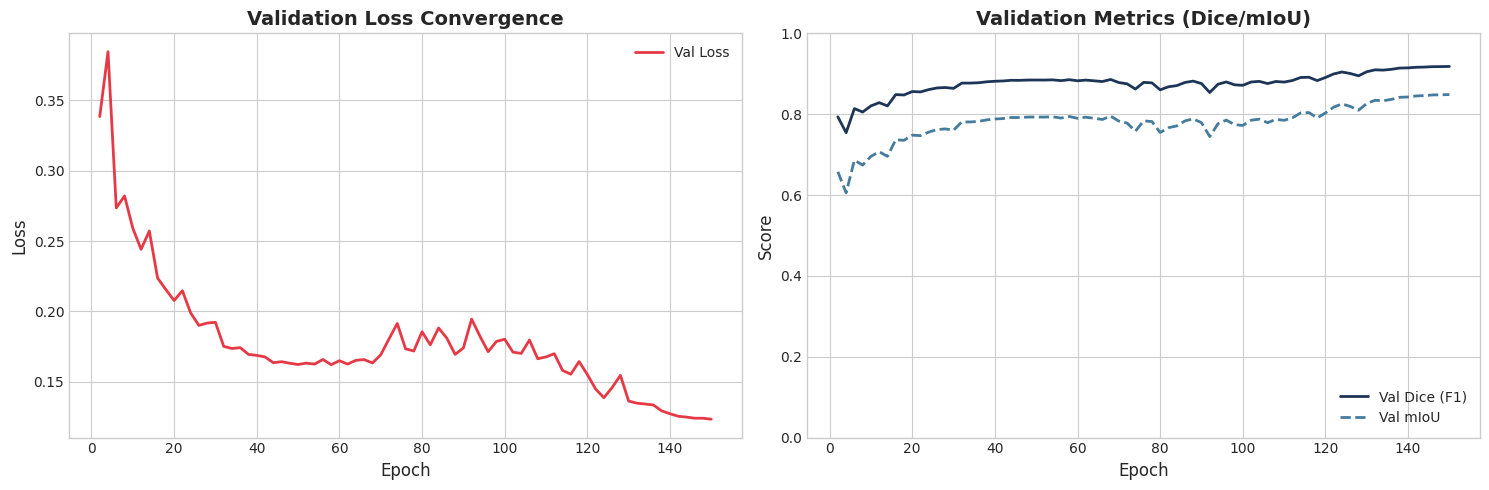

In [2]:
import matplotlib.pyplot as plt
import re
import os

# ================= 1. Configure path (update to your latest log path) =================
LOG_FILE = "/gpfs/work/bio/yixuanli2204/FYP_Project/code/UltraLight-VM-UNet/results/UltraLight_VM_UNet_ISIC_Combined_20260323_best/log/train.info.log"

def generate_curves(log_path):
    epochs = []
    val_losses = []
    val_dice = []
    val_miou = []

    # Use regular expression to extract data from logs
    # Expected format: val epoch: 10, loss: 0.2541, miou: 0.7812, f1_or_dsc: 0.8245
    pattern = r"val epoch: (\d+), loss: ([\d\.]+), miou: ([\d\.]+), f1_or_dsc: ([\d\.]+)"

    if not os.path.exists(log_path):
        print(f"Error: Log file not found: {log_path}")
        return

    with open(log_path, 'r') as f:
        for line in f:
            match = re.search(pattern, line)
            if match:
                epochs.append(int(match.group(1)))
                val_losses.append(float(match.group(2)))
                val_miou.append(float(match.group(3)))
                val_dice.append(float(match.group(4)))

    # ================= 2. Plotting =================
    plt.style.use('seaborn-whitegrid')  # Use an academic-style background
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Subplot A: Validation Loss curve
    ax1.plot(epochs, val_losses, color='#E63946', linewidth=2, label='Val Loss')
    ax1.set_title('Validation Loss Convergence', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend()

    # Subplot B: Dice & mIoU curves (most important)
    ax2.plot(epochs, val_dice, color='#1D3557', linewidth=2, label='Val Dice (F1)')
    ax2.plot(epochs, val_miou, color='#457B9D', linewidth=2, linestyle='--', label='Val mIoU')
    ax2.set_title('Validation Metrics (Dice/mIoU)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Score', fontsize=12)
    ax2.set_ylim(0, 1.0)  # Score range 0-1
    ax2.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig('training_metrics_curves.png', dpi=300)
    print(f"Validation curves saved: training_metrics_curves.png ({len(epochs)} data points)")
    plt.show()

if __name__ == "__main__":
    generate_curves(LOG_FILE)